In [1]:
import json

data_file = '../configs/config_1_data_17-01-2026_19:47:15.json'

with open(data_file, 'r') as f:
    data = json.load(f) 

print(data)

[{'source': 0, 'dest': 1, 'path': [0, 3, 4, 5, 2, 1], 'bit_syn': {'00': 1058, '01': 1027, '10': 980, '11': 1031}, 'phase_syn': {'00': 986, '01': 1036, '10': 1034, '11': 1040}, 'bit_exec_time': 20.732484102249146, 'phase_exec_time': 22.809356927871704}, {'source': 0, 'dest': 1, 'path': [0, 3, 4, 1], 'bit_syn': {'00': 1027, '01': 1050, '10': 1043, '11': 976}, 'phase_syn': {'00': 994, '01': 1025, '10': 1023, '11': 1054}, 'bit_exec_time': 6.728536128997803, 'phase_exec_time': 8.522387027740479}, {'source': 0, 'dest': 1, 'path': [0, 1], 'bit_syn': {'00': 2883, '01': 413, '10': 403, '11': 397}, 'phase_syn': {'00': 2784, '01': 400, '10': 480, '11': 432}, 'bit_exec_time': 3.8123908042907715, 'phase_exec_time': 5.78571081161499}, {'source': 0, 'dest': 2, 'path': [0, 3, 4, 5, 2], 'bit_syn': {'00': 1040, '01': 995, '10': 1009, '11': 1052}, 'phase_syn': {'00': 997, '01': 1025, '10': 1002, '11': 1072}, 'bit_exec_time': 13.185683965682983, 'phase_exec_time': 16.026030778884888}, {'source': 0, 'dest'

In [2]:
import pickle
import numpy as np
import networkx as nx
from pathlib import Path

# ==========================================
# 1. Class Definition (DO NOT MODIFY)
# ==========================================
# This class definition is required for the pickle file to be readable
# by the training script.
class TimeAwareMeasurement:
    def __init__(self, path_edges, histogram, duration, latency_stats=None, code_type='513'):
        """
        :param path_edges: List of tuples representing the path, e.g., [(0,1), (1,2)]
        :param histogram: A 16-dimensional numpy array of syndrome counts.
        :param duration: The duration or average latency of this measurement (seconds).
        :param latency_stats: A dictionary with 'max', 'std', 'count'.
        :param code_type: String indicating the code type, e.g., '313_X', '313_Z', '513'.
        """
        self.path_edges = path_edges
        self.histogram = histogram
        self.duration = duration
        self.latency_stats = latency_stats
        self.code_type = code_type  # Default, will be updated per sample

# ==========================================
# 2. Main Export Function
# ==========================================
def export_real_data(
    output_dir,
    topology_graph,
    raw_measurement_data,
    physical_params
):
    """
    Saves real data into .pkl files compatible with the training pipeline.

    :param output_dir: String, folder path to save files.
    :param topology_graph: networkx.Graph object representing the physical network.
    :param raw_measurement_data: List of dictionaries containing your real data.
    :param physical_params: Dictionary of physical parameters (T1, T2, etc.).
    """
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    print(f"--- Exporting Data to {output_dir} ---")

    # -------------------------------------------------
    # Step A: Save Graph Topology (graph.pkl)
    # -------------------------------------------------
    # Ensure the graph uses integer Node IDs consistent with path_edges
    with open(output_path / "graph.pkl", "wb") as f:
        pickle.dump(topology_graph, f)
    print(f"[OK] Saved graph.pkl with {len(topology_graph.nodes)} nodes.")

    # -------------------------------------------------
    # Step B: Process and Save Measurements (measurements.pkl)
    # -------------------------------------------------
    formatted_measurements = []

    for sample in raw_measurement_data:
        # 1. Extract raw data from your source
        # sample['path']: e.g., [0, 1, 2]
        # sample['counts']: e.g., [100, 5, 2, 0] (for 313 code)
        # sample['code']: '313_X' or '313_Z' or '513'
       
        # --- CRITICAL 1: Format Path Edges ---
        # Convert list of nodes [0, 1, 2] -> list of sorted edges [(0,1), (1,2)]
        node_path = sample['path']
        edges = []
        for i in range(len(node_path) - 1):
            u, v = node_path[i], node_path[i+1]
            # Edges MUST be sorted: (min, max)
            edges.append(tuple(sorted((u, v))))

        # --- CRITICAL 2: Format Histogram (Padding) ---
        # The training model strictly requires an input dimension of 16.
        # Even if you use 313 codes (4 syndromes), you must pad with zeros.
       
        raw_counts = np.array(sample['counts'], dtype=np.float32)
        padded_histogram = np.zeros(16, dtype=np.float32)

        # Copy real data into the beginning of the array
        # If 313 code (len 4), indices 0-3 are filled, 4-15 remain 0.
        # If 513 code (len 16), indices 0-15 are filled.
        current_len = len(raw_counts)
        padded_histogram[:current_len] = raw_counts

        # --- 3. Create Object ---
        meas_obj = TimeAwareMeasurement(
            path_edges=edges,
            histogram=padded_histogram,
            duration=sample['duration'],  # in seconds
            latency_stats=sample.get('stats', {'max': 0, 'std': 0, 'count': 0})
        )
        meas_obj.code_type = sample['code'] # Explicitly set code type
       
        formatted_measurements.append(meas_obj)

    with open(output_path / "measurements.pkl", "wb") as f:
        pickle.dump(formatted_measurements, f)
    print(f"[OK] Saved measurements.pkl with {len(formatted_measurements)} samples.")

    # -------------------------------------------------
    # Step C: Save Metadata (metadata.pkl)
    # -------------------------------------------------
    # This helps the script normalize time values.
    # Calculate min/max time from your actual data if not provided.
    durations = [m.duration for m in formatted_measurements]
   
    metadata = {
        't1': physical_params.get('t1', 1.0),
        't2': physical_params.get('t2', 1.0),
        'alpha': physical_params.get('alpha', 0.6),
        'min_time': min(durations) if durations else 0.0,
        'max_time': max(durations) if durations else 1.0,
        'test_pairs': [] # Optional: list of (src, dst) tuples reserved for testing
    }
   
    with open(output_path / "metadata.pkl", "wb") as f:
        pickle.dump(metadata, f)
    print("[OK] Saved metadata.pkl")


# ==========================================
# 3. Usage Example (How your collaborator uses it)
# ==========================================
if __name__ == "__main__":
    # --- TODO: Define your Topology ---
    # Create a NetworkX graph matching your real setup
    my_graph = nx.Graph()
    my_graph.add_edges_from([(0, 1), (1, 2), (2, 3)])

    # --- TODO: Load your REAL data here ---
    # This is just an example of the structure they need to construct from their logs
    my_real_data = [
        {
            'path': [0, 1, 2],            # Path taken
            'counts': [80, 10, 5, 5],     # REAL syndrome counts (size 4 for 313)
            'code': '313_X',              # Code type
            'duration': 0.005,            # Latency in seconds
            'stats': {'max': 0.01, 'std': 0.001, 'count': 100}
        },
        {
            'path': [1, 2, 3],
            'counts': [90, 2, 8, 0],
            'code': '313_Z',
            'duration': 0.004,
            'stats': {'max': 0.008, 'std': 0.001, 'count': 100}
        }
    ]

    # --- TODO: Define Physical Params ---
    my_params = {'t1': 1000, 't2': 500, 'alpha': 0.6}

    # Run the export
    # export_real_data("../real_experiment_data", my_graph, my_real_data, my_params)

In [3]:
formatted_measurement_data = []
for measurement in data:
    print(measurement)
    path = measurement['path']
    path_tuples = list(zip(path[:-1], path[1:]))
    print(path_tuples)
    bit_syndrome = list(measurement['bit_syn'].values())
    phase_syndrome = list(measurement['phase_syn'].values())
    print(bit_syndrome, phase_syndrome)
    bit_syn_time = measurement['bit_exec_time'] / sum(bit_syndrome)
    phase_syn_time = measurement['phase_exec_time'] / sum(phase_syndrome)
    print(bit_syn_time, phase_syn_time)
    bit_syndrome_measurement = TimeAwareMeasurement(
        path_edges=path_tuples,
        histogram=np.array(bit_syndrome + [0]*12, dtype=np.float32),
        duration=bit_syn_time,
        code_type='313_X'
    )
    phase_syndrome_measurement = TimeAwareMeasurement(
        path_edges=path_tuples,
        histogram=np.array(phase_syndrome + [0]*12, dtype=np.float32),
        duration=phase_syn_time,
        code_type='313_Z'
    )

    formatted_measurement_data.append(bit_syndrome_measurement)
    formatted_measurement_data.append(phase_syndrome_measurement)


# Save to pickle file
output_path = Path("../pickle_files/")
output_path.mkdir(parents=True, exist_ok=True)
infro_tag = '_'.join(data_file.split('_')[-2:]).rstrip('.json')
measurements_file = output_path / f"measurements_{infro_tag}.pkl"
with open(measurements_file, "wb") as f:
    pickle.dump(formatted_measurement_data, f)




{'source': 0, 'dest': 1, 'path': [0, 3, 4, 5, 2, 1], 'bit_syn': {'00': 1058, '01': 1027, '10': 980, '11': 1031}, 'phase_syn': {'00': 986, '01': 1036, '10': 1034, '11': 1040}, 'bit_exec_time': 20.732484102249146, 'phase_exec_time': 22.809356927871704}
[(0, 3), (3, 4), (4, 5), (5, 2), (2, 1)]
[1058, 1027, 980, 1031] [986, 1036, 1034, 1040]
0.00506164162652567 0.005568690656218678
{'source': 0, 'dest': 1, 'path': [0, 3, 4, 1], 'bit_syn': {'00': 1027, '01': 1050, '10': 1043, '11': 976}, 'phase_syn': {'00': 994, '01': 1025, '10': 1023, '11': 1054}, 'bit_exec_time': 6.728536128997803, 'phase_exec_time': 8.522387027740479}
[(0, 3), (3, 4), (4, 1)]
[1027, 1050, 1043, 976] [994, 1025, 1023, 1054]
0.0016427090158686042 0.0020806608954444528
{'source': 0, 'dest': 1, 'path': [0, 1], 'bit_syn': {'00': 2883, '01': 413, '10': 403, '11': 397}, 'phase_syn': {'00': 2784, '01': 400, '10': 480, '11': 432}, 'bit_exec_time': 3.8123908042907715, 'phase_exec_time': 5.78571081161499}
[(0, 1)]
[2883, 413, 403, 

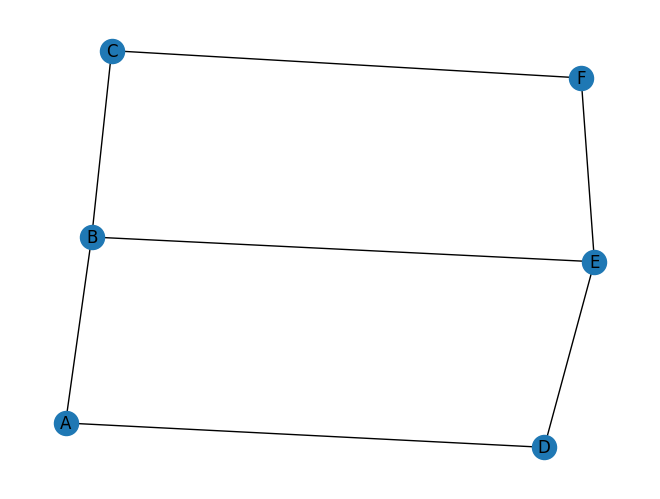

In [4]:

import rustworkx
from rustworkx.visualization import graphviz_draw

def node_attr(node):
    return {'label':node[1]}

NODE_NAMES = {
    0: 'A',
    1: 'B',
    2: 'C',
    3: 'D',
    4: 'E',
    5: 'F',
}

NODE_NAMES_REVERSE = {v: k for k, v in NODE_NAMES.items()}


network_graph = nx.Graph()
# Add the edges: 
# A -- B -- C
# |    |    |
# D -- E -- F

network_graph.add_edge(NODE_NAMES_REVERSE.get('A'), NODE_NAMES_REVERSE.get('B'))
network_graph.add_edge(NODE_NAMES_REVERSE.get('B'), NODE_NAMES_REVERSE.get('C'))
network_graph.add_edge(NODE_NAMES_REVERSE.get('A'), NODE_NAMES_REVERSE.get('D'))
network_graph.add_edge(NODE_NAMES_REVERSE.get('B'), NODE_NAMES_REVERSE.get('E'))
network_graph.add_edge(NODE_NAMES_REVERSE.get('C'), NODE_NAMES_REVERSE.get('F'))
network_graph.add_edge(NODE_NAMES_REVERSE.get('D'), NODE_NAMES_REVERSE.get('E'))
network_graph.add_edge(NODE_NAMES_REVERSE.get('E'), NODE_NAMES_REVERSE.get('F'))

nx.draw(network_graph, with_labels=True, labels=NODE_NAMES)

In [5]:
graph_file = output_path / "2x3_grid_network_graph.pkl"
with open(graph_file, "wb") as f:
        pickle.dump(network_graph, f)